# 线性回归（Linear Regression）—— PyTorch 实现详解

> 参考：《动手学深度学习》(Dive into Deep Learning) — 李沐 (Mu Li)

---

## 目录

1. 什么是线性回归？—— 数学原理
2. 生成合成数据集
3. 从零实现线性回归（手动梯度下降）
4. 使用 `nn.Module` 实现线性回归
5. 使用 `nn.Sequential` + 优化器的简洁实现
6. 训练过程可视化
7. 多变量线性回归（Multiple Linear Regression）
8. 真实数据集实践（Boston Housing 简化版）
9. 总结与对比

---

## 1. 什么是线性回归？—— 数学原理

### 1.1 问题定义

线性回归（Linear Regression）是机器学习中最基础、最重要的模型之一。它的目标是：

> 给定一组输入特征 $\mathbf{X} = [x_1, x_2, \dots, x_d]$，
> 预测一个连续的输出值 $\hat{y}$。

### 1.2 数学模型

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b$$

向量形式：

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b$$

其中：
- $\mathbf{w} = [w_1, w_2, \dots, w_d]^T$ — **权重（weight）**
- $b$ — **偏置（bias）**
- $\mathbf{x} = [x_1, x_2, \dots, x_d]^T$ — **输入特征**
- $\hat{y}$ — **预测值**

### 1.3 损失函数 —— 均方误差（MSE）

我们使用 **均方误差（Mean Squared Error, MSE）** 来衡量模型的好坏：

$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

其中 $y_i$ 是真实值，$\hat{y}_i$ 是预测值，$n$ 是样本数。

### 1.4 优化方法 —— 梯度下降（Gradient Descent）

梯度下降的核心思想：**沿着损失函数梯度的反方向更新参数**，使损失不断减小。

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial L}{\partial \mathbf{w}}$$

$$b \leftarrow b - \eta \frac{\partial L}{\partial b}$$

其中 $\eta$ 是**学习率（learning rate）**，控制每次更新的步长。

### 1.5 梯度推导（关键！）

对 MSE 损失函数求偏导：

$$\frac{\partial L}{\partial \mathbf{w}} = \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} + b - \mathbf{y})$$

$$\frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

理解这个求导过程对理解整个神经网络的训练至关重要！

---

## 2. 生成合成数据集

我们首先按照真实情况模拟：已知真实参数，生成带有噪声的数据。

- 真实模型：$y = 2x_1 - 3.4x_2 + 4.2$
- 添加高斯噪声 $\epsilon \sim \mathcal{N}(0, 0.01)$ 模拟真实场景中的测量误差

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 设置中文字体（如果可用）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========================================
# 数据生成参数
# ========================================
num_inputs = 2       # 特征维度 d = 2
num_examples = 1000  # 样本数量 n = 1000

# 真实参数（我们希望模型学会的参数）
true_w = torch.tensor([2.0, -3.4])  # 权重
true_b = 4.2                          # 偏置

# ========================================
# 生成特征 X ~ N(0, 1)
# ========================================
features = torch.tensor(
    np.random.normal(0, 1, (num_examples, num_inputs)), 
    dtype=torch.float32
)

# ========================================
# 生成标签 y = Xw + b + ε
# ========================================
labels = true_w[0] * features[:, 0] + true_w[1] * features[:, 1] + true_b
labels += torch.tensor(
    np.random.normal(0, 0.01, size=labels.size()), 
    dtype=torch.float32
)

print(f"Features 形状: {features.shape}")  # (1000, 2)
print(f"Labels 形状:   {labels.shape}")     # (1000,)
print(f"\n前5个样本:")
print(f"features:\n{features[:5]}")
print(f"labels:\n{labels[:5]}")
print(f"\n真实参数: w={true_w.tolist()}, b={true_b}")

Features 形状: torch.Size([1000, 2])
Labels 形状:   torch.Size([1000])

前5个样本:
features:
tensor([[ 0.0668,  1.5093],
        [-0.3459,  0.7699],
        [ 0.7241,  1.0231],
        [-0.5030,  0.1631],
        [ 1.0137,  0.5116]])
labels:
tensor([-0.7920,  0.8805,  2.1758,  2.6467,  4.4831])

真实参数: w=[2.0, -3.4000000953674316], b=4.2


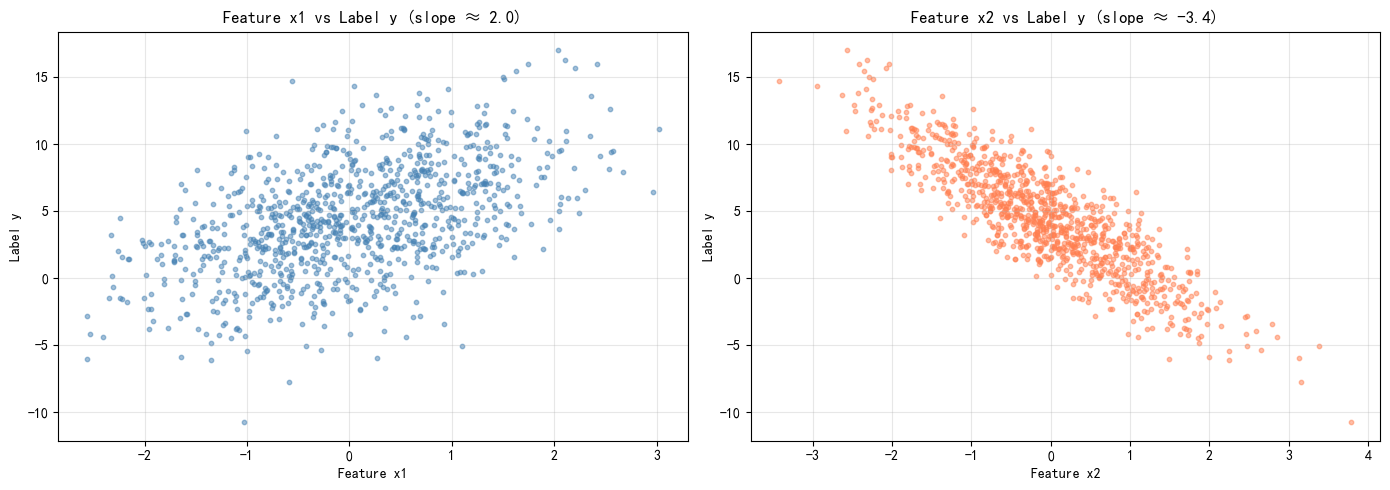

In [4]:
# ========================================
# 数据可视化
# ========================================
fig = plt.figure(figsize=(14, 5))

# 子图1: 特征 x1 与标签的关系
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(features[:, 0].numpy(), labels.numpy(), alpha=0.5, s=10, c='steelblue')
ax1.set_xlabel('Feature x1')
ax1.set_ylabel('Label y')
ax1.set_title('Feature x1 vs Label y (slope ≈ 2.0)')
ax1.grid(True, alpha=0.3)

# 子图2: 特征 x2 与标签的关系
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(features[:, 1].numpy(), labels.numpy(), alpha=0.5, s=10, c='coral')
ax2.set_xlabel('Feature x2')
ax2.set_ylabel('Label y')
ax2.set_title('Feature x2 vs Label y (slope ≈ -3.4)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. 从零实现线性回归（手动梯度下降）

**这是最重要的部分！** 亲手实现每个步骤，理解 PyTorch 自动求导的本质。

### 流程：
1. 初始化参数 $\mathbf{w}, b$
2. 前向传播：计算预测值 $\hat{y} = \mathbf{X}\mathbf{w} + b$
3. 计算损失：$L = \frac{1}{n}\sum(\hat{y} - y)^2$
4. 反向传播：自动计算梯度
5. 更新参数：$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_\mathbf{w} L$

In [5]:
# ========================================
# 步骤1: 初始化参数
# ========================================
torch.manual_seed(42)

# 使用正态分布随机初始化权重，偏置初始化为0
w = torch.normal(0, 0.01, size=(num_inputs, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

print(f"初始 w (requires_grad={w.requires_grad}):\n{w}")
print(f"初始 b (requires_grad={b.requires_grad}):\n{b}")
print(f"\n真实 w: {true_w.tolist()}")
print(f"真实 b: {true_b}")

# 解释：为什么 requires_grad=True？
# → 因为我们需要 PyTorch 追踪这些张量上的所有操作，
#   以便调用 .backward() 时自动计算梯度。

初始 w (requires_grad=True):
tensor([[0.0034],
        [0.0013]], requires_grad=True)
初始 b (requires_grad=True):
tensor([0.], requires_grad=True)

真实 w: [2.0, -3.4000000953674316]
真实 b: 4.2


In [6]:
# ========================================
# 定义模型、损失函数
# ========================================

def linear_model(X, w, b):
    """前向传播：线性模型 y_hat = X @ w + b
    
    Args:
        X: 特征矩阵, shape (n, d)
        w: 权重, shape (d, 1)
        b: 偏置, shape (1,)
    Returns:
        预测值, shape (n, 1)
    """
    
    return torch.matmul(X, w) + b  # 等价于 X @ w + b


def mse_loss(y_hat, y):
    """均方误差损失
    
    Args:
        y_hat: 预测值, shape (n, 1)
        y: 真实值, shape (n,)
    Returns:
        标量损失值
    """
    return ((y_hat - y.reshape(-1, 1)) ** 2).mean() / 2  # 除2是为了梯度更干净


# 验证前向传播
y_hat_test = linear_model(features[:5], w, b)
print(f"测试前向传播 (5个样本):\n{y_hat_test}")
print(f"真实值:\n{labels[:5].reshape(-1, 1)}")

测试前向传播 (5个样本):
tensor([[ 0.0022],
        [-0.0002],
        [ 0.0038],
        [-0.0015],
        [ 0.0041]], grad_fn=<AddBackward0>)
真实值:
tensor([[-0.7920],
        [ 0.8805],
        [ 2.1758],
        [ 2.6467],
        [ 4.4831]])


In [7]:
# ========================================
# 定义数据迭代器（必须在训练前定义！）
# ========================================

def data_iter(batch_size, features, labels):
    """
    小批量数据迭代器
    
    将数据打乱后按 batch_size 分批取出，
    训练神经网络时基本都会用这种方式。
    
    Args:
        batch_size: 每批样本数
        features: 特征 (n, d)
        labels: 标签 (n,)
    Yields:
        (batch_features, batch_labels)
    """
    n = len(features)
    # 随机打乱索引
    indices = list(range(n))
    np.random.shuffle(indices)
    
    for i in range(0, n, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, n)])
        yield features[batch_indices], labels[batch_indices]


# ========================================
# 训练循环（核心！）
# ========================================

lr = 0.03          # 学习率
num_epochs = 100   # 迭代次数
batch_size = 10    # 小批量大小（用于随机梯度下降 SGD）

# 记录训练过程
loss_history = []
w_history = []   # 记录w的变化
b_history = []   # 记录b的变化

for epoch in range(num_epochs):
    # ---- 小批量随机梯度下降（Mini-batch SGD） ----
    for X_batch, y_batch in data_iter(batch_size, features, labels):
        # ① 前向传播：计算预测值
        y_hat = linear_model(X_batch, w, b)
        
        # ② 计算损失
        loss = mse_loss(y_hat, y_batch)
        
        # ③ 反向传播：计算梯度 (autograd!)
        loss.backward()
        
        # ④ 梯度下降更新参数（在 no_grad 中）
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            
            # ⑤ 清零梯度（重要！否则会累积）
            w.grad.zero_()
            b.grad.zero_()
    
    # ---- 每个 epoch 结束后计算全量损失 ----
    with torch.no_grad():
        total_loss = mse_loss(linear_model(features, w, b), labels)
        loss_history.append(total_loss.item())
        w_history.append(w.detach().clone())
        b_history.append(b.detach().clone())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs}, '
              f'Loss = {total_loss.item():.6f}, '
              f'w = [{w[0].item():.4f}, {w[1].item():.4f}], '
              f'b = {b.item():.4f}')

Epoch  20/100, Loss = 0.000050, w = [1.9996, -3.4001], b = 4.1995
Epoch  40/100, Loss = 0.000050, w = [1.9997, -3.4002], b = 4.1995
Epoch  60/100, Loss = 0.000050, w = [2.0001, -3.4002], b = 4.1997
Epoch  80/100, Loss = 0.000050, w = [2.0001, -3.3996], b = 4.1992
Epoch 100/100, Loss = 0.000050, w = [2.0002, -3.3998], b = 4.1993


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

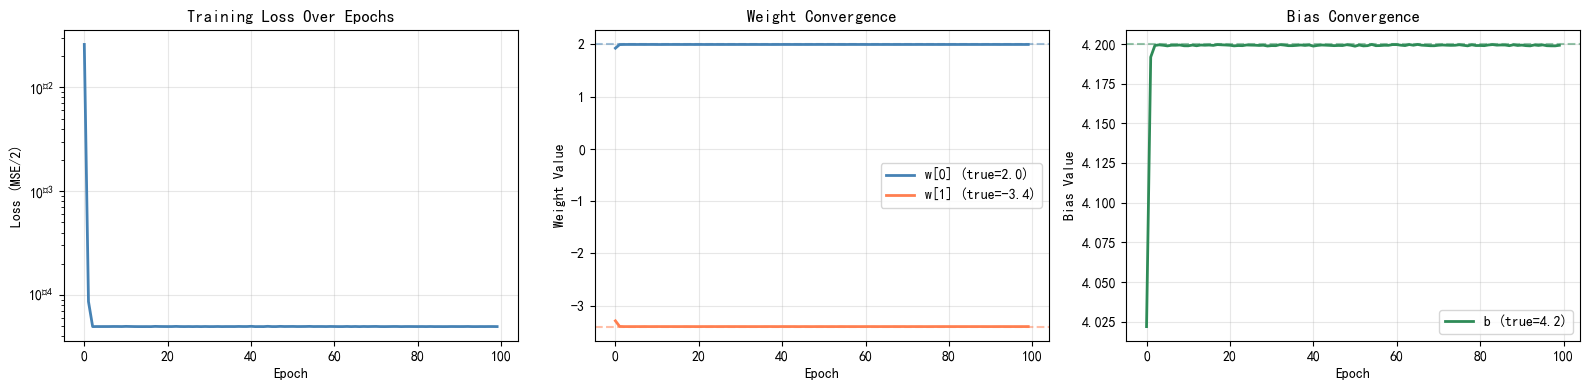

In [8]:
# ========================================
# 损失函数下降曲线
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 子图1: Loss 下降
ax = axes[0]
ax.plot(loss_history, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE/2)')
ax.set_title('Training Loss Over Epochs')
ax.set_yscale('log')  # 对数坐标更容易观察
ax.grid(True, alpha=0.3)

# 子图2: 权重 w 的收敛过程
ax = axes[1]
w1_history = [w[0].item() for w in w_history]
w2_history = [w[1].item() for w in w_history]
ax.plot(w1_history, label='w[0] (true=2.0)', color='steelblue', linewidth=2)
ax.plot(w2_history, label='w[1] (true=-3.4)', color='coral', linewidth=2)
ax.axhline(y=true_w[0].item(), color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(y=true_w[1].item(), color='coral', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Weight Value')
ax.set_title('Weight Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3: 偏置 b 的收敛过程
ax = axes[2]
b_vals = [b.item() for b in b_history]
ax.plot(b_vals, label='b (true=4.2)', color='seagreen', linewidth=2)
ax.axhline(y=true_b, color='seagreen', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Bias Value')
ax.set_title('Bias Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.1 关键知识点回顾（手动实现）

| 步骤 | 操作 | 说明 |
|------|------|------|
| ① 初始化 | `w, b = randn(...), zeros(1)`, `requires_grad=True` | 参数需要梯度 |
| ② 前向传播 | `y_hat = X @ w + b` | 计算预测值 |
| ③ 计算损失 | `loss = MSE(y_hat, y)` | 标量，PyTorch会构建计算图 |
| ④ 反向传播 | `loss.backward()` | 自动计算 $\partial L/\partial w$ 和 $\partial L/\partial b$ |
| ⑤ 更新参数 | `w -= lr * w.grad` (在 `no_grad` 中) | 沿着梯度的反方向 |
| ⑥ 梯度清零 | `w.grad.zero_()` | **必须做！** 否则梯度累积 |

### 3.2 常见陷阱

- ❌ **忘记 `zero_()`**：梯度会累积，导致参数更新错误
- ❌ **在 `no_grad()` 外更新参数**：会破坏计算图
- ❌ **学习率太大**：参数发散，Loss 爆炸
- ❌ **学习率太小**：收敛太慢

---

## 4. 使用 `nn.Module` 实现线性回归

了解了手动实现后，我们来看看 PyTorch 提供的更高层次的抽象。

PyTorch 提供了：
- `nn.Module`：封装模型参数和前向传播
- `nn.Linear`：线性层（全连接层），等价于 $\mathbf{X}\mathbf{w} + b$
- `nn.MSELoss`：均方误差损失
- `torch.optim.SGD`：随机梯度下降优化器

In [9]:
import torch.nn as nn
import torch.optim as optim

# ========================================
# 方式A: 自定义 nn.Module 子类
# ========================================

class LinearRegression(nn.Module):
    """
    自定义线性回归模型
    
    继承 nn.Module 只需要做两件事：
    1. __init__: 定义网络层（参数会自动注册）
    2. forward: 定义前向传播逻辑
    """
    def __init__(self, input_dim):
        super().__init__()
        # nn.Linear(in_features, out_features, bias=True)
        # 内部自动初始化 w 和 b，且 requires_grad=True
        self.linear = nn.Linear(input_dim, 1, bias=True)
        
    def forward(self, x):
        """前向传播"""
        return self.linear(x)


# 创建模型
torch.manual_seed(42)
model = LinearRegression(num_inputs)

print(f"模型结构:\n{model}")
print(f"\n模型参数:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, requires_grad={param.requires_grad}")
    print(f"    值:\n{param.data}")

模型结构:
LinearRegression(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)

模型参数:
  linear.weight: shape=torch.Size([1, 2]), requires_grad=True
    值:
tensor([[0.5406, 0.5869]])
  linear.bias: shape=torch.Size([1]), requires_grad=True
    值:
tensor([-0.1657])


In [10]:
# ========================================
# 训练（使用 nn.Module）
# ========================================

torch.manual_seed(42)
model = LinearRegression(num_inputs)

# PyTorch 内置的损失函数
criterion = nn.MSELoss(reduction='mean')  # reduction='mean' 是默认值

# PyTorch 内置的优化器
optimizer = optim.SGD(model.parameters(), lr=0.03)

print(f"损失函数: {criterion}")
print(f"优化器:   {optimizer}")
print(f"\nmodel.parameters() 返回: {list(model.parameters())}")

损失函数: MSELoss()
优化器:   SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.03
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

model.parameters() 返回: [Parameter containing:
tensor([[0.5406, 0.5869]], requires_grad=True), Parameter containing:
tensor([-0.1657], requires_grad=True)]


In [11]:
# ========================================
# 训练循环（nn.Module 版本）
# ========================================

num_epochs = 100
batch_size = 10
loss_history_v2 = []

for epoch in range(num_epochs):
    for X_batch, y_batch in data_iter(batch_size, features, labels):
        # ① 前向传播
        y_hat = model(X_batch)
        
        # ② 计算损失
        loss = criterion(y_hat.squeeze(), y_batch)
        
        # ③ 反向传播
        optimizer.zero_grad()  # 等价于对所有参数调用 .grad.zero_()
        loss.backward()
        
        # ④ 更新参数
        optimizer.step()  # 等价于对所有参数执行 w -= lr * w.grad
    
    # 记录损失
    with torch.no_grad():
        total_loss = criterion(model(features).squeeze(), labels)
        loss_history_v2.append(total_loss.item())
    
    if (epoch + 1) % 20 == 0:
        # 获取当前参数
        w_learned = model.linear.weight.data
        b_learned = model.linear.bias.data
        print(f'Epoch {epoch+1:3d}/{num_epochs}, '
              f'Loss = {total_loss.item():.6f}, '
              f'w = [{w_learned[0, 0].item():.4f}, {w_learned[0, 1].item():.4f}], '
              f'b = {b_learned.item():.4f}')

Epoch  20/100, Loss = 0.000100, w = [1.9999, -3.3998], b = 4.1988
Epoch  40/100, Loss = 0.000100, w = [2.0000, -3.4004], b = 4.1991
Epoch  60/100, Loss = 0.000101, w = [1.9990, -3.3993], b = 4.1998
Epoch  80/100, Loss = 0.000100, w = [1.9994, -3.4007], b = 4.1994
Epoch 100/100, Loss = 0.000100, w = [1.9998, -3.3996], b = 4.1989


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

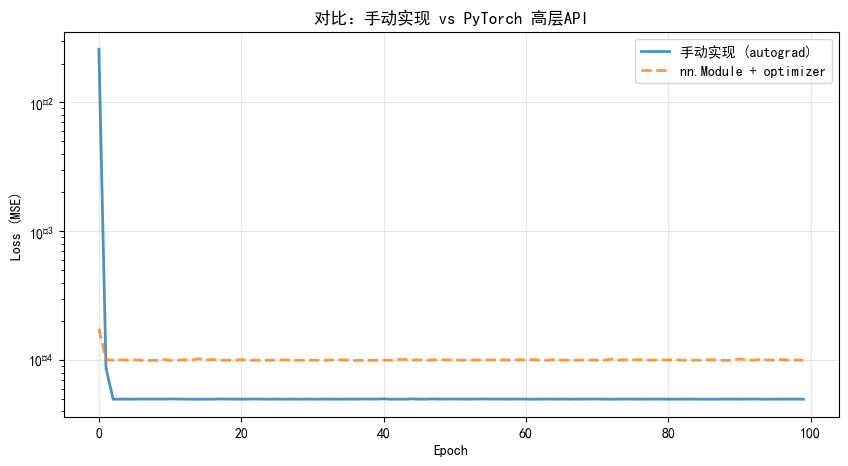


两条曲线几乎重合——说明底层原理完全一致！


In [12]:
# ========================================
# 对比手动实现 vs nn.Module 实现
# ========================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_history, label='手动实现 (autograd)', linewidth=2, alpha=0.8)
ax.plot(loss_history_v2, label='nn.Module + optimizer', linewidth=2, alpha=0.8, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('对比：手动实现 vs PyTorch 高层API')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("\n两条曲线几乎重合——说明底层原理完全一致！")

### 4.1 手动实现 vs nn.Module 对比

| 操作 | 手动实现 | nn.Module |
|------|----------|-----------|
| 参数初始化 | `torch.normal(...)` | `nn.Linear` 自动完成 |
| 前向传播 | `X @ w + b` | `model(X)` |
| 损失函数 | 自己写 `mse_loss()` | `nn.MSELoss()` |
| 梯度清零 | `w.grad.zero_()` 逐个调用 | `optimizer.zero_grad()` 一步完成 |
| 参数更新 | `w -= lr * w.grad` 逐个更新 | `optimizer.step()` 一步完成 |
| 参数管理 | 手动管理每个Tensor | `model.parameters()` 统一管理 |

---

## 5. 使用 `nn.Sequential` + 优化器的极简实现

对于线性回归这种简单模型，我们甚至不需要自定义类。`nn.Sequential` 可以将各层串联起来。

In [13]:
# ========================================
# 最简洁的实现方式
# ========================================

torch.manual_seed(42)

# 一行定义模型
model_seq = nn.Sequential(nn.Linear(num_inputs, 1))

# 定义损失和优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(model_seq.parameters(), lr=0.03)

print(f"模型: {model_seq}")
print(f"参数: {list(model_seq.parameters())}")

模型: Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)
参数: [Parameter containing:
tensor([[0.5406, 0.5869]], requires_grad=True), Parameter containing:
tensor([-0.1657], requires_grad=True)]


In [14]:
# ========================================
# 极简训练循环
# ========================================

num_epochs = 100
loss_history_v3 = []

for epoch in range(num_epochs):
    for X_batch, y_batch in data_iter(batch_size, features, labels):
        loss = criterion(model_seq(X_batch).squeeze(), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        loss_history_v3.append(
            criterion(model_seq(features).squeeze(), labels).item()
        )
    
    if (epoch + 1) % 20 == 0:
        w = model_seq[0].weight.data
        b = model_seq[0].bias.data
        print(f'Epoch {epoch+1:3d}: Loss={loss_history_v3[-1]:.6f}, '
              f'w=[{w[0,0]:.4f}, {w[0,1]:.4f}], b={b.item():.4f}')

Epoch  20: Loss=0.000100, w=[1.9996, -3.4002], b=4.1990
Epoch  40: Loss=0.000101, w=[2.0004, -3.4009], b=4.1992
Epoch  60: Loss=0.000100, w=[2.0003, -3.4001], b=4.1988
Epoch  80: Loss=0.000100, w=[1.9992, -3.3997], b=4.1994
Epoch 100: Loss=0.000100, w=[1.9994, -3.3993], b=4.1990


---

## 6. 训练过程可视化

用 3D 可视化来直观理解线性回归模型如何拟合数据。

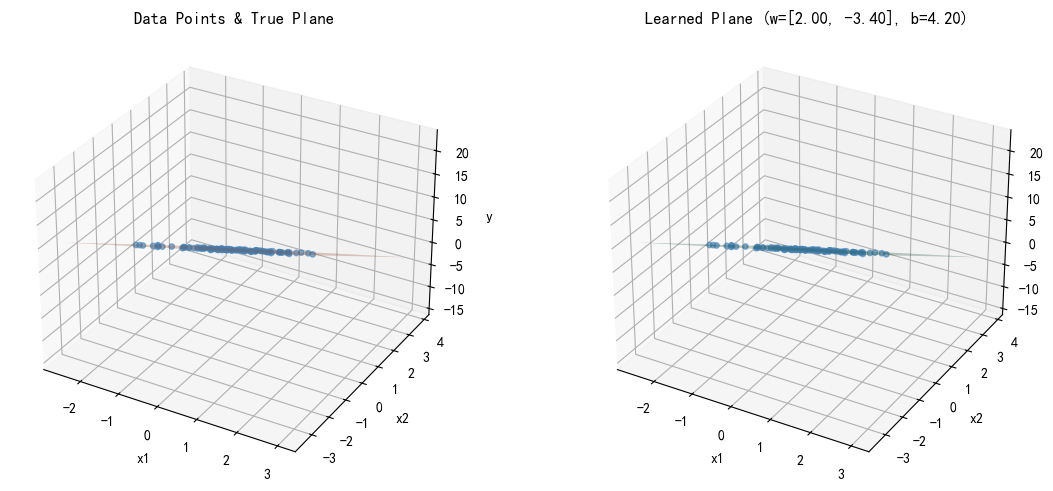

左图：真实平面（数据由此生成）
右图：模型学到的平面——几乎与真实平面重合！


In [15]:
# ========================================
# 3D 可视化：数据点与拟合平面
# ========================================

fig = plt.figure(figsize=(12, 5))

# 子图1: 真实平面 vs 数据点
ax = fig.add_subplot(1, 2, 1, projection='3d')
x1, x2 = features[:, 0].numpy(), features[:, 1].numpy()
ax.scatter(x1[::10], x2[::10], labels.numpy()[::10], 
           c='steelblue', alpha=0.6, s=15, label='Data (noisy)')

# 生成网格来绘制真实平面
x1_grid = np.linspace(x1.min(), x1.max(), 20)
x2_grid = np.linspace(x2.min(), x2.max(), 20)
x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)
y_true_mesh = true_w[0].item() * x1_mesh + true_w[1].item() * x2_mesh + true_b

ax.plot_surface(x1_mesh, x2_mesh, y_true_mesh, alpha=0.3, color='coral', label='True Plane')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Data Points & True Plane')

# 子图2: 学到的平面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
w_learned = model_seq[0].weight.data.numpy()
b_learned = model_seq[0].bias.data.item()
y_pred_mesh = w_learned[0, 0] * x1_mesh + w_learned[0, 1] * x2_mesh + b_learned

ax2.scatter(x1[::10], x2[::10], labels.numpy()[::10], 
            c='steelblue', alpha=0.6, s=15, label='Data')
ax2.plot_surface(x1_mesh, x2_mesh, y_pred_mesh, alpha=0.3, color='seagreen', label='Learned Plane')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title(f'Learned Plane (w=[{w_learned[0,0]:.2f}, {w_learned[0,1]:.2f}], b={b_learned:.2f})')

plt.tight_layout()
plt.show()

print("左图：真实平面（数据由此生成）")
print("右图：模型学到的平面——几乎与真实平面重合！")

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

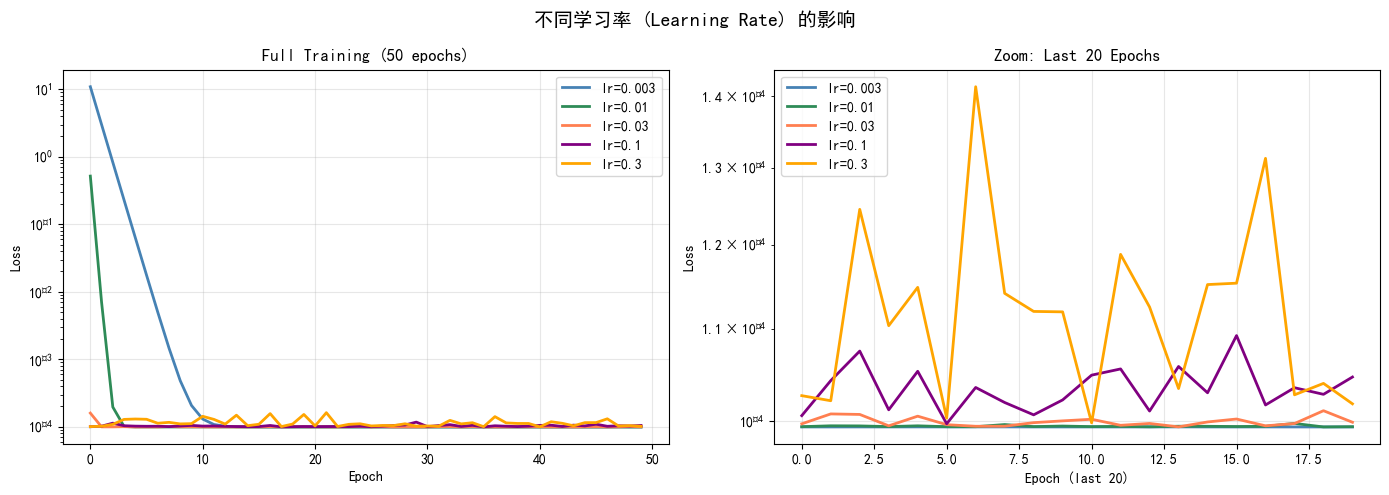

观察：
  - lr=0.003: 收敛太慢
  - lr=0.03:  收敛速度合适，最终loss小
  - lr=0.3:   可能震荡甚至发散！


In [16]:
# ========================================
# 不同学习率下 Loss 曲线的对比
# ========================================

def train_with_lr(lr, num_epochs=50):
    """用给定的学习率训练并返回loss历史"""
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(2, 1))
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(num_epochs):
        for X_batch, y_batch in data_iter(10, features, labels):
            loss = criterion(model(X_batch).squeeze(), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            losses.append(criterion(model(features).squeeze(), labels).item())
    
    return losses


learning_rates = [0.003, 0.01, 0.03, 0.1, 0.3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'seagreen', 'coral', 'purple', 'orange']
for lr, color in zip(learning_rates, colors):
    losses = train_with_lr(lr)
    axes[0].plot(losses, label=f'lr={lr}', color=color, linewidth=2)
    axes[1].plot(losses[-20:], label=f'lr={lr}', color=color, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Full Training (50 epochs)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch (last 20)')
axes[1].set_ylabel('Loss')
axes[1].set_title('Zoom: Last 20 Epochs')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('不同学习率 (Learning Rate) 的影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("观察：")
print("  - lr=0.003: 收敛太慢")
print("  - lr=0.03:  收敛速度合适，最终loss小")
print("  - lr=0.3:   可能震荡甚至发散！")

---

## 7. 多变量线性回归（Multiple Linear Regression）

当特征维度 $d > 2$ 时，模型形式不变，但无法直接可视化。
我们来演示一个更高维的例子。

In [17]:
# ========================================
# 高维线性回归 (d = 10)
# ========================================

# 生成数据
torch.manual_seed(123)
np.random.seed(123)

d_high = 10               # 10个特征
n_samples = 2000          # 2000个样本

# 真实参数
true_w_high = torch.randn(d_high, 1)
true_b_high = torch.tensor(3.5)

# 生成特征和标签
X_high = torch.randn(n_samples, d_high)
y_high = X_high @ true_w_high + true_b_high + torch.randn(n_samples, 1) * 0.05

print(f"数据形状: X={X_high.shape}, y={y_high.shape}")
print(f"真实参数: b={true_b_high.item():.2f}, w 前5个={true_w_high[:5].squeeze().tolist()}")

数据形状: X=torch.Size([2000, 10]), y=torch.Size([2000, 1])
真实参数: b=3.50, w 前5个=[-0.11146711558103561, 0.12036294490098953, -0.3696345090866089, -0.2404179722070694, -1.1969243288040161]


In [18]:
# ========================================
# 训练高维线性模型
# ========================================

model_high = nn.Sequential(nn.Linear(d_high, 1))
criterion = nn.MSELoss()
optimizer = optim.SGD(model_high.parameters(), lr=0.1)

loss_history_high = []

for epoch in range(100):
    # 小批量
    for i in range(0, n_samples, 32):
        X_batch = X_high[i:i+32]
        y_batch = y_high[i:i+32]
        
        loss = criterion(model_high(X_batch), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        total_loss = criterion(model_high(X_high), y_high)
        loss_history_high.append(total_loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/100, Loss = {total_loss.item():.6f}')

# 对比学到的参数和真实参数
w_high_learned = model_high[0].weight.data.squeeze()
b_high_learned = model_high[0].bias.data.item()

print(f"\n{'='*50}")
print(f"参数对比 (10维)")
print(f"{'='*50}")
print(f"{'维度':<8} {'真实w':<12} {'学习到w':<12} {'误差':<12}")
print(f"{'-'*44}")
for i in range(d_high):
    tw = true_w_high[i].item()
    lw = w_high_learned[i].item()
    print(f"w[{i}]    {tw:<12.4f} {lw:<12.4f} {abs(tw-lw):<12.6f}")
print(f"{'bias':<8} {true_b_high.item():<12.4f} {b_high_learned:<12.4f} {abs(true_b_high.item()-b_high_learned):<12.6f}")

Epoch  20/100, Loss = 0.002599
Epoch  40/100, Loss = 0.002599
Epoch  60/100, Loss = 0.002599
Epoch  80/100, Loss = 0.002599
Epoch 100/100, Loss = 0.002599

参数对比 (10维)
维度       真实w          学习到w         误差          
--------------------------------------------
w[0]    -0.1115      -0.1150      0.003485    
w[1]    0.1204       0.1180       0.002323    
w[2]    -0.3696      -0.3630      0.006592    
w[3]    -0.2404      -0.2414      0.000997    
w[4]    -1.1969      -1.1931      0.003839    
w[5]    0.2093       0.2060       0.003278    
w[6]    -0.9724      -0.9744      0.002067    
w[7]    -0.7550      -0.7549      0.000150    
w[8]    0.3239       0.3233       0.000577    
w[9]    -0.1085      -0.1090      0.000475    
bias     3.5000       3.5023       0.002292    


---

## 8. 真实数据集实践：California Housing

用真实数据来巩固所学知识。我们使用 sklearn 中的 California Housing 数据集（替代难以获取的 Boston Housing 数据集）。

这是一个经典的回归问题：根据房屋特征预测房价。

In [19]:
# ========================================
# 加载真实数据集
# ========================================

try:
    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    
    # 加载数据
    housing = fetch_california_housing()
    X_real = housing.data      # shape: (20640, 8)
    y_real = housing.target    # shape: (20640,)
    
    print(f"数据集信息:")
    print(f"  特征维度: {X_real.shape[1]}")
    print(f"  样本数量: {X_real.shape[0]}")
    print(f"  特征名称: {housing.feature_names}")
    print(f"  描述: {housing.DESCR[:200]}...")
    
except ImportError:
    print("请先安装 sklearn: pip install scikit-learn")
    # 使用简单数据作为fallback
    X_real = np.random.randn(500, 5)
    y_real = X_real @ np.array([2.0, -1.0, 3.0, -0.5, 1.5]) + 5.0 + np.random.randn(500) * 0.1

数据集信息:
  特征维度: 8
  样本数量: 20640
  特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  描述: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attribu...


In [20]:
# ========================================
# 数据预处理
# ========================================

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

# 标准化（极其重要！）
# 让每个特征的均值为0，标准差为1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为 PyTorch Tensor
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(f"训练集: X={X_train_t.shape}, y={y_train_t.shape}")
print(f"测试集: X={X_test_t.shape}, y={y_test_t.shape}")
print(f"\n标准化后——训练集均值: {X_train_t.mean(dim=0)}")
print(f"标准化后——训练集标准差: {X_train_t.std(dim=0)}")

训练集: X=torch.Size([16512, 8]), y=torch.Size([16512, 1])
测试集: X=torch.Size([4128, 8]), y=torch.Size([4128, 1])

标准化后——训练集均值: tensor([-1.5017e-09,  9.2410e-09, -1.1551e-10,  0.0000e+00, -6.9308e-10,
        -9.2410e-10,  2.3103e-09,  0.0000e+00])
标准化后——训练集标准差: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [21]:
# ========================================
# 定义模型并训练
# ========================================

input_dim = X_train_t.shape[1]

model_real = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# 注意：这里用了两层隐藏层+ReLU激活，这其实已经是神经网络了！
# 去掉隐藏层就是纯线性回归。我们保留它们来展示简单的MLP。

criterion = nn.MSELoss()
optimizer = optim.Adam(model_real.parameters(), lr=0.01)  # Adam 优化器

print(f"模型结构:\n{model_real}")

模型结构:
Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [22]:
# ========================================
# 训练
# ========================================

num_epochs = 200
batch_size = 64
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    # ---- 训练阶段 ----
    model_real.train()
    for i in range(0, len(X_train_t), batch_size):
        X_batch = X_train_t[i:i+batch_size]
        y_batch = y_train_t[i:i+batch_size]
        
        optimizer.zero_grad()
        loss = criterion(model_real(X_batch), y_batch)
        loss.backward()
        optimizer.step()
    
    # ---- 评估阶段 ----
    model_real.eval()
    with torch.no_grad():
        train_loss = criterion(model_real(X_train_t), y_train_t).item()
        test_loss = criterion(model_real(X_test_t), y_test_t).item()
        train_losses.append(train_loss)
        test_losses.append(test_loss)
    
    if (epoch + 1) % 40 == 0:
        print(f'Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}')

print(f"\n最终: Train Loss={train_losses[-1]:.4f}, Test Loss={test_losses[-1]:.4f}")

Epoch  40: Train Loss=0.2571, Test Loss=0.2992
Epoch  80: Train Loss=0.2363, Test Loss=0.2949
Epoch 120: Train Loss=0.2239, Test Loss=0.2921
Epoch 160: Train Loss=0.2264, Test Loss=0.2983
Epoch 200: Train Loss=0.2275, Test Loss=0.3147

最终: Train Loss=0.2275, Test Loss=0.3147


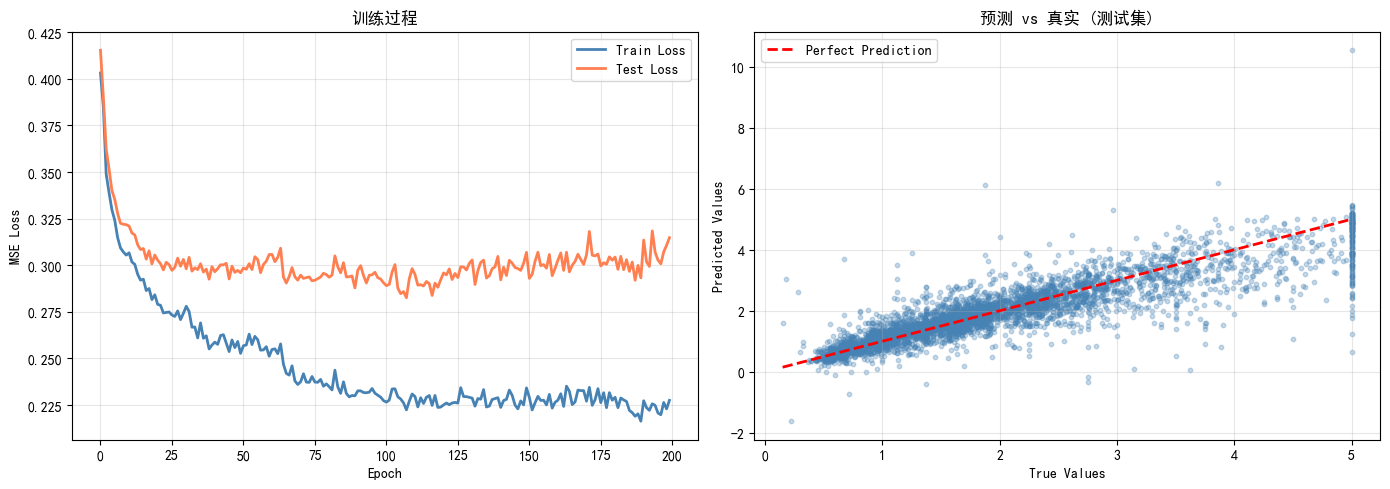

散点越靠近红色虚线，说明预测越准确。


In [23]:
# ========================================
# 训练/测试 Loss 曲线
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(test_losses, label='Test Loss', color='coral', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('训练过程')
ax.legend()
ax.grid(True, alpha=0.3)

# 预测值与真实值的散点图
ax = axes[1]
with torch.no_grad():
    y_pred = model_real(X_test_t).squeeze().numpy()
    y_true = y_test_t.squeeze().numpy()

ax.scatter(y_true, y_pred, alpha=0.3, s=10, c='steelblue')
ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
        '--', color='red', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('预测 vs 真实 (测试集)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("散点越靠近红色虚线，说明预测越准确。")

---

## 9. 总结与对比

### 9.1 三种实现方式对比

| 方式 | 代码量 | 灵活性 | 推荐场景 |
|------|--------|--------|----------|
| **手动实现** (autograd) | 多 | 最高 | 学习原理、理解底层 |
| **nn.Module 子类** | 中 | 高 | 自定义复杂模型 |
| **nn.Sequential** | 少 | 中 | 简单顺序模型 |

### 9.2 核心知识清单

- [x] 线性回归的数学模型：$\hat{y} = \mathbf{w}^T\mathbf{x} + b$
- [x] 损失函数 MSE：$L = \frac{1}{n}\sum(\hat{y} - y)^2$
- [x] 梯度下降：$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_\mathbf{w}L$
- [x] 小批量随机梯度下降（Mini-batch SGD）
- [x] `requires_grad` + `backward()` + `no_grad` 的配合使用
- [x] `nn.Module` / `nn.Linear` / `nn.Sequential`
- [x] `nn.MSELoss` / `optim.SGD` / `optim.Adam`
- [x] 数据标准化的重要性
- [x] 学习率对训练的影响

### 9.3 从线性回归到神经网络

线性回归是最简单的"神经元"。如果把多个线性层用非线性激活函数连接起来，就得到了**多层感知机（MLP）**，也就是我们常说的神经网络！

```
线性回归: Input → Linear → Output (回归)
神经网络: Input → Linear → ReLU → Linear → ReLU → Linear → Output
```

理解了线性回归，你就理解了深度学习最核心的训练范式：

> **前向传播 → 计算损失 → 反向传播 → 更新参数 → 循环迭代**

这个框架适用于从最简单的线性回归到最复杂的 GPT 模型！

In [24]:
# ========================================
# 最终总结：训练深度模型的通用模板
# ========================================

def training_template(model, train_loader, criterion, optimizer, num_epochs):
    """
    深度学习训练循环的通用模板
    
    这个模板适用于 99% 的深度学习任务！
    
    Args:
        model: nn.Module 模型
        train_loader: DataLoader 训练数据加载器
        criterion: 损失函数
        optimizer: 优化器
        num_epochs: 训练轮数
    """
    for epoch in range(num_epochs):
        # ========== 训练阶段 ==========
        model.train()  # 切换到训练模式（影响 Dropout、BatchNorm 等）
        
        for X_batch, y_batch in train_loader:
            # 1. 前向传播
            y_pred = model(X_batch)
            
            # 2. 计算损失
            loss = criterion(y_pred, y_batch)
            
            # 3. 反向传播 + 更新
            optimizer.zero_grad()   # 清零梯度
            loss.backward()         # 计算梯度
            optimizer.step()        # 更新参数
        
        # ========== 评估阶段 ==========
        model.eval()  # 切换到评估模式
        with torch.no_grad():  # 不追踪梯度
            # 计算验证集损失或指标
            pass
    
    print("训练完成！")

print("✅ 这就是深度学习训练的通用模板！记住它！")

✅ 这就是深度学习训练的通用模板！记住它！


---

## 推荐阅读

- **《动手学深度学习》** — 李沐 著 → [d2l.ai](https://d2l.ai/)
  - 第3章：线性神经网络
  - 第3.2节：线性回归的从零开始实现
  - 第3.3节：线性回归的简洁实现
- **PyTorch 官方文档**: [pytorch.org/docs/stable/](https://pytorch.org/docs/stable/)
- 本目录下的 `tensor_base_std.ipynb`：Tensor 基础知识（建议先掌握）

---

## 下一步

掌握了线性回归后，你可以继续学习：
1. Softmax 回归（多分类）
2. 多层感知机（MLP）—— 真正的神经网络
3. 卷积神经网络（CNN）
4. 循环神经网络（RNN / LSTM）
5. Transformer / Attention

Happy Learning! 🎉